# Datos

En los *notebooks* se presentan ejemplos para cada una de las herramientas presentadas. Muchos de estos ejemplos son obtenidos de las diferentes fuentes utilizadas en este libro, como del libro de los profesores Sergio Rey (Universidad del Estado de San Diego), Dani Arribas-Bel (Universidad de Liverpool) y Levi Wolf (Universidad de Bristol) denominado [Geographic data science with Python](https://geographicdata.science/book/intro.html#). Adicionalmente se presenta un caso local de los Andes Colombianos en torno a la ocurrencia de movimientos en masa utilizando como unidad de análisis subcuencas.

El área de estudio se encuentra al norte de 5°N y abarca las Cordilleras Occidental y Central de los Andes colombianos, separadas por el cañón del Cauca. La región está delimitada por el río Atrato al oeste y el río Magdalena al este. Cubriendo aproximadamente 50,000 $km^2$, el área está dividida en 533 subcuencas dentro de las cuencas hidrográficas del Atrato (25% de las cuencas), Cauca (50%) y Magdalena (25%). Aproximadamente el 73% de estas cuencas tienen áreas menores de 100 $km^2$, con un área media de 48 $km^2$.

Se cuenta con un catálogo de 13,777 deslizamientos superficiales y profundos que ocurrieron entre 1970 y 2023, detectados visualmente utilizando imágenes ópticas de alta resolución ($<$1 m) en color real de Google Earth™ y Planet Scope con resolucion espacial de 3-4 m.

Como variables predictoras para el área de estudio se eentran área bajo la curva hipsométrica de la subcuenca, elevación media, pendiente media, relieve local medio, precipitación media anual, número de días con precipitación diaria acumulada $>20$ mm, cobertura del suelo y geología predominante. 

Los parámetros del terreno se calcularon utilizando el modelo digital de elevación (DEM) del radar de apertura sintética en banda L del satélite de observación terrestre Aaanzada (ALOS-PALSAR), con una resolución de píxel de 12.5 m (Logan 2014).

Las métricas de precipitación se derivaron utilizando los datos de CHIRPS (*Climate Hazard Group InfraRed Precipitation with Station Data*) (Funk 2015), versión 2.0, para datos de precipitación con una resolución de 5 km desde 1981 hasta 2023. Para este cálculo se utilizó la plataforma Google Earth Engine (GEE) con lenguaje Javascript.

Se generó un mapa de cobertura del suelo utilizando datos del programa Copernicus Sentinel-2, con una resolución de 10 m. Utilizando GEE, seleccionamos imágenes desde 2018 hasta 2023 con menos del 10% de cobertura de nubes, eliminando efectos de sombra. El mapa se creó calculando el índice de vegetación de diferencia normalizada (NDVI) (Kriegler 1969), el índice de diferencia normalizada de construcciones (NDBI) (Zha et al. 2003), el índice de diferencia normalizada de agua modificado (MNDWI) (Xu 2006) y el índice de suelo desnudo (BSI) (Li 2014). La clasificación de cobertura del suelo se realizó con un algoritmo de bosque aleatorio (*random forest*) del paquete Classifier de GEE (Breiman 2001).

<center><img src="https://i.pinimg.com/736x/2e/0e/3a/2e0e3af953227d328e79677b4aa4b2cf.jpg" width="600"></center>

Los datos pueden ser obtenidos del repositorio de Github https://github.com/edieraristizabal/ModeloMultinivel/tree/main

A continuación se presenta la forma de descargar los datos y su visualización.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

Una forma directa es con geopandas, ya que es un archivo espacial tipo *gpkg*:

In [ ]:
gdf = gpd.read_file("https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg")
gdf.info()

Tambien es posible, primero descargando el archivo y luego leerlo en *Python*:

In [ ]:
import requests
from io import BytesIO

url = "https://github.com/edieraristizabal/ModeloMultinivel/raw/refs/heads/main/DATA/df_catchments_spatial.gpkg"

try:
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Lanza una excepción para errores HTTP

    # Lee el contenido descargado como un archivo en memoria
    with BytesIO(response.content) as f:
        gdf = gpd.read_file(f)

    gdf.info()

except requests.exceptions.RequestException as e:
    print(f"Error al descargar el archivo: {e}")
except Exception as e:
    print(f"Error al leer el archivo GPKG: {e}")

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   526 non-null    int64   
 1   Nombre               526 non-null    object  
 2   ID_CUENCA            526 non-null    float64 
 3   cuenca               526 non-null    object  
 4   area                 526 non-null    int64   
 5   elev_mean            526 non-null    float64 
 6   elev_median          526 non-null    float64 
 7   rel_mean             526 non-null    float64 
 8   rel_median           526 non-null    float64 
 9   rainfallAnnual_mean  526 non-null    float64 
 10  Densidad             526 non-null    float64 
 11  hypso_inte           526 non-null    float64 
 12  slope_mean           526 non-null    float64 
 13  kmeans               526 non-null    object  
 14  RainfallDaysmean     526 non-null    float64 
 15  RainfallDaysmed

In [14]:
gdf.head()

,id,Nombre,ID_CUENCA,cuenca,area,elev_mean,elev_median,rel_mean,rel_median,rainfallAnnual_mean,Densidad,hypso_inte,slope_mean,kmeans,RainfallDaysmean,RainfallDaysmedian,landcovermedian,geomedian,lands_rec,geometry
0,1,Quebrada Guaco,606.0,Cauca,18443928,1615.334363,1607.0,510.665139,505.0,2264.807895,18.230950,0.493,29.278027,C,1112.245024,1066.0,grass,sediment,4.0,"POLYGON ((454732.740 622820.251, 454684.825 62..."
1,2,Quebrada Cabaña,601.0,Cauca,15797104,1485.514279,1443.0,587.551540,590.0,2453.187233,15.837190,0.515,27.276356,C,1381.331112,1416.0,grass,volcanic,6.0,"POLYGON ((445998.990 633523.601, 445938.990 63..."
2,3,Quebrada Circia,268.0,Cauca,41264565,1751.017810,1771.0,479.273145,482.0,2446.462791,17.364213,0.534,27.046340,C,1335.000000,1335.0,grass,granitic,6.0,"POLYGON ((449407.484 638933.816, 449416.943 63..."
3,4,Quebrada Las Yeguas,257.0,Cauca,86871930,2259.304383,2235.0,290.758334,250.0,2415.640307,12.902091,0.636,19.844786,D,1342.000000,1302.5,grass,granitic,8.0,"POLYGON ((449127.882 648864.822, 449150.880 64..."
4,5,Quebrada Daza,255.0,Cauca,28178836,1671.334481,1660.0,488.840365,499.0,2361.272164,22.018253,0.500,28.240738,C,1186.297521,1268.5,grass,granitic,6.0,"POLYGON ((445769.984 646158.816, 445776.576 64..."


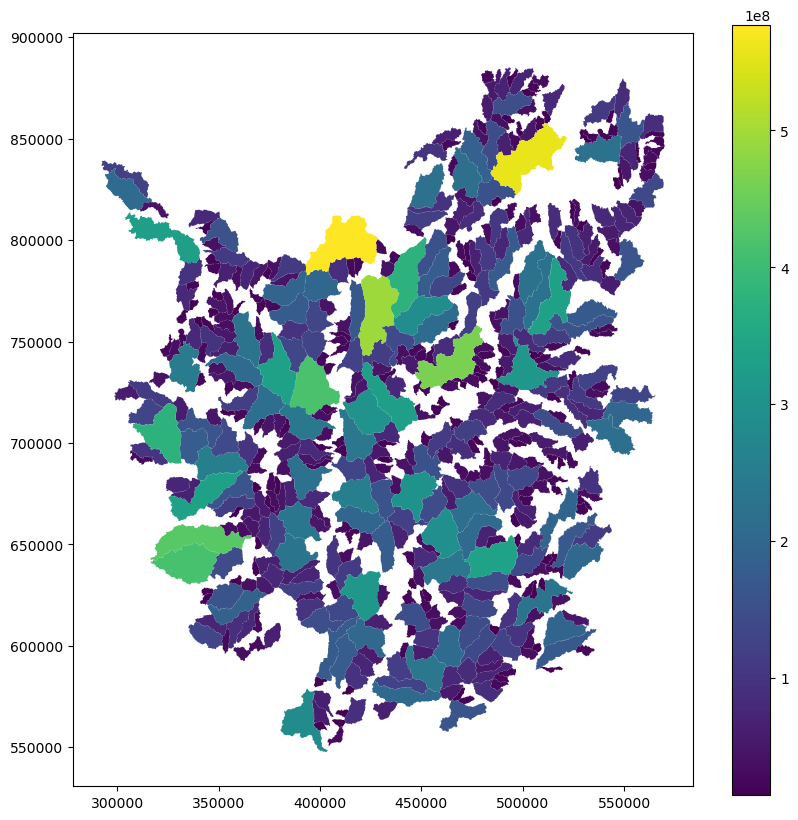

In [19]:
f, ax = plt.subplots(1, figsize=(10, 10))
gdf.plot(column='area', legend=True, ax=ax)
plt.show()

A continuación se presenta la distribución de la variable $Y$, en términos de frecuencia y densidad, asi como su transformación logarítmica.

<center><img src="https://i.pinimg.com/736x/72/c4/9c/72c49c6699dfa17b0abc0723366ed4ec.jpg" width="800"></center>

Estas subcuencas pueden ser agregadas por cuencas hidrográficas de la siguiente manera:

<center><img src="https://i.pinimg.com/736x/69/08/dd/6908dddbdd14c9e12b6226d745671538.jpg" width="600"></center>